In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages] # List of messages in the chat which can be anything like system, human, ai, etc.so we use BaseMessage class
    #add_messages is a decorator that tells langgraph to add the messages to the graph more optimized then opeartor.add

In [4]:
llm = ChatGroq(model="openai/gpt-oss-120b")


def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [5]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

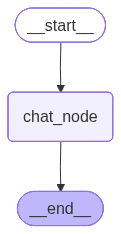

In [6]:
chatbot

In [ ]:
# u hvae to use persistent state to keep the chat history

In [7]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ['exit', 'quit','bye']:
        print("Exiting chat.")
        break


    # Append user message to the chat history
    initial_state['messages'].append(HumanMessage(content=user_input))

    # Invoke the chatbot with the updated state
    response_state = chatbot.invoke(initial_state)

    # Get the latest AI response
    ai_response = response_state['messages'][-1]
    print(f"AI: {ai_response.content}")

    # Update the initial state for the next iteration
    initial_state = response_state

NameError: name 'initial_state' is not defined

In [24]:
initial_state

{'messages': [HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='b7910304-a15a-4a63-93fa-5d7d407b2fe0'),
  AIMessage(content='I don’t have any information about your name. If you’d like, you can tell me what you’d like to be called!', additional_kwargs={'reasoning_content': 'The user asks "what is my name?" There\'s no prior context. As per policy, we must not reveal that we don\'t have that info, but we can say we don\'t know. We must not pretend. So answer: I don\'t know your name. Ask if they\'d like to tell.'}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 76, 'total_tokens': 171, 'completion_time': 0.201536992, 'completion_tokens_details': {'reasoning_tokens': 59}, 'prompt_time': 0.002852795, 'prompt_tokens_details': None, 'queue_time': 0.049896382, 'total_time': 0.204389787}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprob